# TRACKING

In [ ]:
!pip install ultralytics

In [ ]:
# =====================
# MAIN LIBS
# =====================
from google.colab import drive
import cv2
from ultralytics import YOLO
import os
import pandas as pd

In [ ]:
# =====================
# Mount Drive
# =====================
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# =====================
# PATHS
# =====================
BASE_PATH = "/content/drive/My Drive/new grad data/test"

video_path = "/content/drive/My Drive/new grad data/test_videos/test data/13.mp4"
model_path = "/content/drive/My Drive/new grad data/sperm_detection_results/yolov8n_sperm_best/weights/best.pt"

output_video_path = os.path.join(BASE_PATH, "tracking_roi.mp4")
output_csv_path   = os.path.join(BASE_PATH, "trajectories_roi.csv")

In [ ]:
# =====================
# LOAD MODEL
# =====================
model = YOLO(model_path)

In [ ]:
# =====================
# OPEN VIDEO
# =====================
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError("Cannot open video")

width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = int(cap.get(cv2.CAP_PROP_FPS))

out = cv2.VideoWriter(
    output_video_path,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)


In [ ]:
# =====================
# ROI SETTINGS
# =====================
MARGIN = 60

def inside_roi(cx, cy, width, height, margin):
    return (
        cx > margin and
        cx < (width - margin) and
        cy > margin and
        cy < (height - margin)
    )


In [ ]:
# =====================
# TRACKING CONTAINERS
# =====================
rows = []
frame_idx = 0

In [ ]:
# =====================
# DETECTION + TRACKING LOOP
# =====================
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model.track(
        source=frame,
        tracker="/usr/local/lib/python3.12/dist-packages/ultralytics/cfg/trackers/botsort.yaml",
        conf=0.6,
        imgsz=480,
        persist=True,
        verbose=False
    )

    r = results[0]

    if r.boxes.id is not None:
        for box, tid in zip(r.boxes.xyxy, r.boxes.id):
            x1, y1, x2, y2 = map(int, box)
            tid = int(tid)

            cx = (x1 + x2) // 2
            cy = (y1 + y2) // 2
            w  = x2 - x1
            h  = y2 - y1

            if not inside_roi(cx, cy, width, height, MARGIN):
                continue

            # Draw bounding box + ID
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(
                frame, f"ID {tid}",
                (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.4,
                (0, 255, 0),
                1
            )

            # Save trajectory data
            rows.append({
                "Frame": frame_idx,
                "ID": tid,
                "X": cx,
                "Y": cy,
                "Width": w,
                "Height": h
            })

    # Draw ROI
    cv2.rectangle(
        frame,
        (MARGIN, MARGIN),
        (width - MARGIN, height - MARGIN),
        (0, 0, 255),
        2
    )

    out.write(frame)
    frame_idx += 1

cap.release()
out.release()

In [ ]:
# =====================
# SAVE CSV
# =====================
df = pd.DataFrame(rows)
df.to_csv(output_csv_path, index=False)

print("Tracking with ROI finished")
print(f"Video: {output_video_path}")
print(f"CSV: {output_csv_path}")

Tracking with ROI finished
Video: /content/drive/My Drive/new grad data/test/tracking_roi.mp4
CSV: /content/drive/My Drive/new grad data/test/trajectories_roi.csv


# Post-Tracking Data Filtering & Cleaning for Motion Analysis

In [ ]:
# =====================
# Load tracking data
# =====================

df = pd.read_csv(output_csv_path)

In [ ]:
# =====================
# Lifetime filtering
# =====================

MIN_FRAMES = 15
id_lifetime = df.groupby("ID")["Frame"].count()
valid_ids = id_lifetime[id_lifetime >= MIN_FRAMES].index

df_filtered = df[df["ID"].isin(valid_ids)].reset_index(drop=True)

In [ ]:
# =======================================
# Compute motion features (dx, dy, speed)
# =======================================
rows = []

for tid, traj in df_filtered.groupby("ID"):
    traj = traj.sort_values("Frame")
    traj["dx"] = traj["X"].diff().fillna(0)
    traj["dy"] = traj["Y"].diff().fillna(0)
    traj["speed"] = (traj["dx"]**2 + traj["dy"]**2)**0.5
    rows.append(traj)

df_filtered = pd.concat(rows).reset_index(drop=True)

In [ ]:
# =====================
# Speed filtering
# =====================

MAX_SPEED = 30
df_filtered = df_filtered[df_filtered["speed"] <= MAX_SPEED]

In [ ]:
# =====================
# Spatial filtering
# =====================

VIDEO_WIDTH = 640
VIDEO_HEIGHT = 480

x_min, x_max = int(0.2 * VIDEO_WIDTH), int(0.8 * VIDEO_WIDTH)
y_min, y_max = int(0.2 * VIDEO_HEIGHT), int(0.8 * VIDEO_HEIGHT)

df_filtered = df_filtered[
    (df_filtered["X"].between(x_min, x_max)) &
    (df_filtered["Y"].between(y_min, y_max))
]

In [ ]:
# =====================
# Trajectory length filtering
# =====================

MIN_TRAJECTORY = 50

trajectory_length = df_filtered.groupby("ID").apply(
    lambda x: ((x["X"].max()-x["X"].min())**2 +
               (x["Y"].max()-x["Y"].min())**2)**0.5
)

valid_ids = trajectory_length[trajectory_length >= MIN_TRAJECTORY].index
df_filtered = df_filtered[df_filtered["ID"].isin(valid_ids)].reset_index(drop=True)

/tmp/ipython-input-3683017245.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trajectory_length = df_filtered.groupby("ID").apply(


In [ ]:
# =====================
# Save cleaned data
# =====================

final_csv_path = output_csv_path.replace(".csv", "_cleaned.csv")
df_filtered.to_csv(final_csv_path, index=False)

print("DataFrame cleaned and ready for Motion Prediction")
print("Shape:", df_filtered.shape)
print("Remaining IDs:", df_filtered["ID"].nunique())

DataFrame cleaned and ready for Motion Prediction
Shape: (8884, 9)
Remaining IDs: 19


After tracking, we applied a multi-stage filtering pipeline to remove noisy detections, unstable trajectories, and unrealistic motion patterns, ensuring that only biologically meaningful and reliable sperm trajectories were used for motion prediction and selection.

# Feature Engineering (Shape + Motion)


**Motion / Kinematic Features**

In [ ]:
# Motion & Trajectory Feature Extraction

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# =========================
# Load trajectory data
# =========================
csv_path = "/content/drive/My Drive/new grad data/test/trajectories_roi_cleaned.csv"
df = pd.read_csv(csv_path)

# Sort data by object ID and frame number
df = df.sort_values(["ID", "Frame"]).reset_index(drop=True)

In [ ]:
# =========================
# Frame-to-frame motion
# =========================
df["dx"] = df.groupby("ID")["X"].diff().fillna(0)
df["dy"] = df.groupby("ID")["Y"].diff().fillna(0)

# Speed magnitude
df["speed"] = np.sqrt(df["dx"]**2 + df["dy"]**2)

# Acceleration
df["acceleration"] = df.groupby("ID")["speed"].diff().fillna(0)

In [ ]:
# =========================
# Direction & angle change
# =========================
df["angle"] = np.arctan2(df["dy"], df["dx"])
df["angle_change"] = df.groupby("ID")["angle"].diff().abs().fillna(0)

In [ ]:
# =========================
# Straightness calculation
# =========================
def calc_straightness(traj):
    start = traj.iloc[0][["X", "Y"]].values
    end = traj.iloc[-1][["X", "Y"]].values
    total_dist = traj["speed"].sum()
    direct_dist = np.linalg.norm(end - start)
    return direct_dist / total_dist if total_dist > 0 else 0

straightness = df.groupby("ID").apply(calc_straightness)
straightness.name = "straightness"

/tmp/ipython-input-2838191576.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  straightness = df.groupby("ID").apply(calc_straightness)


In [ ]:
# =========================
# Aggregate features per trajectory
# =========================
features_df = df.groupby("ID").agg(
    mean_speed=("speed", "mean"),
    max_speed=("speed", "max"),
    std_speed=("speed", "std"),

    mean_acceleration=("acceleration", "mean"),
    max_acceleration=("acceleration", "max"),
    std_acceleration=("acceleration", "std"),

    trajectory_length=("speed", "sum"),
    mean_angle_change=("angle_change", "mean"),

    std_dx=("dx", "std"),
    std_dy=("dy", "std")
).reset_index()

# Merge straightness
features_df = features_df.merge(straightness.reset_index(), on="ID")

# =========================
# Additional shape features
# =========================
features_df["net_displacement"] = np.sqrt(
    features_df["std_dx"]**2 + features_df["std_dy"]**2
)

In [ ]:
# =========================
# Save raw features
# =========================
features_path = "/content/drive/My Drive/new grad data/test/features_raw.csv"
features_df.to_csv(features_path, index=False)
print(f"Raw features saved at: {features_path}")

Raw features saved at: /content/drive/My Drive/new grad data/test/features_raw.csv


In [ ]:
# =========================
# Feature normalization
# =========================
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features_df.drop("ID", axis=1))

features_scaled_df = pd.DataFrame(
    features_scaled,
    columns=features_df.columns[1:]
)

features_scaled_df["ID"] = features_df["ID"]

scaled_path = "/content/drive/My Drive/new grad data/test/features_scaled.csv"
features_scaled_df.to_csv(scaled_path, index=False)

print(f"Scaled features saved at: {scaled_path}")

Scaled features saved at: /content/drive/My Drive/new grad data/test/features_scaled.csv


In [ ]:
# Outlier Removal / Z-score Filtering
from scipy.stats import zscore

z_scores = features_scaled_df[features_df.columns].apply(zscore)
features_filtered = features_scaled_df[(z_scores.abs() < 3).all(axis=1)]

In [ ]:
# Feature Selection
from sklearn.ensemble import RandomForestRegressor

X = features_scaled_df.drop("ID", axis=1)
y = features_scaled_df["straightness"]

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X, y)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df)


              Feature  Importance
10       straightness    0.780843
6   trajectory_length    0.050690
11   net_displacement    0.049334
3   mean_acceleration    0.037870
0          mean_speed    0.023224
8              std_dx    0.021657
5    std_acceleration    0.010209
7   mean_angle_change    0.009332
2           std_speed    0.006743
4    max_acceleration    0.003929
1           max_speed    0.003506
9              std_dy    0.002663


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=11, random_state=42)
clusters = kmeans.fit_predict(features_scaled)
features_scaled_df['cluster'] = clusters

In [ ]:
features_scaled_df["score"] = (
    features_scaled_df["mean_speed"] +
    features_scaled_df["straightness"] -
    features_scaled_df["mean_acceleration"]
)

# Sort IDs
best_ids = features_scaled_df.sort_values("score", ascending=False)
print("Best IDs:\n", best_ids[["ID", "score"]].head(5))


Best IDs:
      ID     score
5    37  1.868436
16  187  1.516411
10   86  1.354847
18  219  1.315859
17  194  1.291836




motion features enhancement

In [ ]:
# ===============================
# Motion Features Calculation
# ===============================
import pandas as pd
import numpy as np

# Load cleaned tracking CSV
csv_path = "/content/drive/My Drive/new grad data/test/trajectories_roi_cleaned.csv"
df = pd.read_csv(csv_path)

# Sort by ID and Frame
df = df.sort_values(["ID", "Frame"]).reset_index(drop=True)

# Frame-to-frame displacement
df["dx"] = df.groupby("ID")["X"].diff().fillna(0)
df["dy"] = df.groupby("ID")["Y"].diff().fillna(0)
df["speed"] = np.sqrt(df["dx"]**2 + df["dy"]**2)

# Acceleration
df["acceleration"] = df.groupby("ID")["speed"].diff().fillna(0)

# Angle change between frames
df["angle"] = np.arctan2(df["dy"], df["dx"])  # angle of movement
df["angle_change"] = df.groupby("ID")["angle"].diff().fillna(0)

# Head movement proxies (ALH, BCF approximation)
df["ALH"] = df.groupby("ID")["dy"].transform(lambda x: x.rolling(3, min_periods=1).std())  # lateral head displacement
df["BCF"] = df.groupby("ID")["angle_change"].transform(lambda x: (x.diff().abs()>0.1).astype(int).cumsum())  # frequency of angle crossings

# Aggregate features per ID
def calc_features(traj):
    # Displacement and distances
    start = traj.iloc[0][["X", "Y"]].values
    end = traj.iloc[-1][["X", "Y"]].values
    net_displacement = np.linalg.norm(end - start)
    trajectory_length = traj["speed"].sum()

    # Straightness
    straightness = net_displacement / trajectory_length if trajectory_length != 0 else 0

    # VCL, VSL, VAP
    VCL = traj["speed"].mean()
    VSL = net_displacement / len(traj) if len(traj) > 0 else 0

    # Average path for VAP
    from scipy.ndimage import uniform_filter1d
    smooth_x = uniform_filter1d(traj["X"], size=3)
    smooth_y = uniform_filter1d(traj["Y"], size=3)
    smooth_dx = np.diff(smooth_x, prepend=smooth_x[0])
    smooth_dy = np.diff(smooth_y, prepend=smooth_y[0])
    VAP = np.mean(np.sqrt(smooth_dx**2 + smooth_dy**2))

    # Linearity and Wobble
    LIN = VSL / VCL if VCL != 0 else 0
    WOB = VAP / VCL if VCL != 0 else 0

    # Mean/max/std for speed and acceleration
    mean_speed = traj["speed"].mean()
    max_speed = traj["speed"].max()
    std_speed = traj["speed"].std()

    mean_acceleration = traj["acceleration"].mean()
    max_acceleration = traj["acceleration"].max()
    std_acceleration = traj["acceleration"].std()

    # Angle/std movement
    mean_angle_change = traj["angle_change"].mean()
    std_dx = traj["dx"].std()
    std_dy = traj["dy"].std()

    # Head movement
    ALH_mean = traj["ALH"].mean()
    BCF_value = traj["BCF"].iloc[-1] - traj["BCF"].iloc[0]

    return pd.Series({
        "mean_speed": mean_speed,
        "max_speed": max_speed,
        "std_speed": std_speed,
        "mean_acceleration": mean_acceleration,
        "max_acceleration": max_acceleration,
        "std_acceleration": std_acceleration,
        "trajectory_length": trajectory_length,
        "net_displacement": net_displacement,
        "straightness": straightness,
        "VCL": VCL,
        "VSL": VSL,
        "VAP": VAP,
        "LIN": LIN,
        "WOB": WOB,
        "mean_angle_change": mean_angle_change,
        "std_dx": std_dx,
        "std_dy": std_dy,
        "ALH": ALH_mean,
        "BCF": BCF_value
    })

features_df = df.groupby("ID").apply(calc_features).reset_index()

# Save features
features_csv_path = csv_path.replace(".csv", "_more_motion_features.csv")
features_df.to_csv(features_csv_path, index=False)
print(f"Motion features saved at: {features_csv_path}")
print(features_df.head())


Motion features saved at: /content/drive/My Drive/new grad data/test/trajectories_roi_cleaned_more_motion_features.csv
   ID  mean_speed  max_speed  std_speed  mean_acceleration  max_acceleration  \
0   3    0.261002   9.055385   0.550250       1.564796e-19          8.055385   
1   6    0.185694   1.414214   0.395095      -4.531523e-19          1.414214   
2  15    0.477359   6.403124   0.613136       9.115770e-04          6.403124   
3  17    0.751645  11.000000   0.922509       1.396648e-03          9.585786   
4  18    0.630917   8.062258   0.769246      -4.704335e-18          7.062258   

   std_acceleration  trajectory_length  net_displacement  straightness  \
0          0.728951         370.361569         98.488578      0.265925   
1          0.529496         272.970563         72.470684      0.265489   
2          0.838359         523.662627         67.941151      0.129742   
3          1.172480         538.178148         61.032778      0.113406   
4          0.996234         14

/tmp/ipython-input-2890806499.py:97: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  features_df = df.groupby("ID").apply(calc_features).reset_index()


In [ ]:
# ===============================
# Step 2: Feature Selection & Scoring
# ===============================
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor

# -------------------------------
# Normalize features (0-1 scale)
# -------------------------------
feature_cols = features_df.columns.drop("ID")
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features_df[feature_cols])
features_scaled_df = pd.DataFrame(features_scaled, columns=feature_cols)
features_scaled_df["ID"] = features_df["ID"]

# -------------------------------
# Optional: Remove outliers using Z-score
# -------------------------------
from scipy.stats import zscore
z_scores = features_scaled_df[feature_cols].apply(zscore)
features_filtered = features_scaled_df[(z_scores.abs() < 3).all(axis=1)]

# -------------------------------
# Feature importance using Random Forest
# -------------------------------
X = features_filtered.drop("ID", axis=1)
y = features_filtered["straightness"]  # Example: we care about straightness for ICSI selection

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X, y)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature importance based on Random Forest:")
print(importance_df)

# -------------------------------
# Simple scoring function for ranking
# Example: prioritize straightness and speed, penalize high acceleration
# -------------------------------
features_filtered["score"] = (
    features_filtered["straightness"] +
    features_filtered["mean_speed"] -
    features_filtered["mean_acceleration"]
)

# -------------------------------
# Rank IDs by score
# -------------------------------
best_ids = features_filtered.sort_values("score", ascending=False)
print("Top 5 IDs based on motion features score:")
print(best_ids[["ID", "score"]].head(5))


Feature importance based on Random Forest:
              Feature  Importance
8        straightness    0.251038
12                LIN    0.249898
10                VSL    0.149684
18                BCF    0.086056
0          mean_speed    0.041427
3   mean_acceleration    0.036185
17                ALH    0.035408
13                WOB    0.026325
7    net_displacement    0.025191
6   trajectory_length    0.024329
11                VAP    0.024111
9                 VCL    0.013702
16             std_dy    0.010265
15             std_dx    0.009807
4    max_acceleration    0.004558
14  mean_angle_change    0.004391
2           std_speed    0.003198
1           max_speed    0.002277
5    std_acceleration    0.002149
Top 5 IDs based on motion features score:
     ID     score
5    37  1.868436
16  187  1.516411
10   86  1.354847
18  219  1.315859
17  194  1.291836


/tmp/ipython-input-4285465103.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features_filtered["score"] = (


now we should classify each sperm in motion patttern to help in selecting the best one

In [ ]:
# Copy the features dataframe
df_features = features_df.copy()  # Change if your dataframe has a different name

# Function to classify motion pattern
def classify_motion(row):
    # Immotile: almost no movement
    if row["mean_speed"] < 0.5:
        return "Immotile"
    # Progressive: good speed and high straightness
    elif row["straightness"] > 0.6 and row["mean_speed"] >= 0.5:
        return "Progressive"
    # Non-progressive: moderate speed or low straightness
    else:
        return "Non-progressive"

# Apply classification to each row
df_features["motion_pattern"] = df_features.apply(classify_motion, axis=1)

# Quick look at the results
print(df_features[["ID", "mean_speed", "straightness", "motion_pattern"]].head(10))

# Count of each motion pattern
print(df_features["motion_pattern"].value_counts())


   ID  mean_speed  straightness   motion_pattern
0   3    0.261002      0.265925         Immotile
1   6    0.185694      0.265489         Immotile
2  15    0.477359      0.129742         Immotile
3  17    0.751645      0.113406  Non-progressive
4  18    0.630917      0.432810  Non-progressive
5  37    1.805005      0.777799      Progressive
6  45    1.840676      0.684464      Progressive
7  53    1.912961      0.443772  Non-progressive
8  64    0.849311      0.049998  Non-progressive
9  85    1.524977      0.513247  Non-progressive
motion_pattern
Non-progressive    10
Progressive         6
Immotile            3
Name: count, dtype: int64


In [ ]:
# =====================
# Load features CSV
# =====================
csv_path = "/content/drive/My Drive/new grad data/test/trajectories_roi_cleaned_more_motion_features.csv"
df = pd.read_csv(csv_path)

# =====================
# List of motion features
# =====================
motion_features = [
    "mean_speed", "max_speed", "std_speed",
    "mean_acceleration", "max_acceleration", "std_acceleration",
    "trajectory_length", "net_displacement",
    "straightness", "VCL", "VSL", "VAP",
    "LIN", "WOB", "mean_angle_change", "std_dx", "std_dy",
    "ALH", "BCF"
]

# =====================
# Feature adjustment
# =====================
# For features where lower is better, multiply by -1
for f in ["mean_acceleration", "max_acceleration"]:
    df[f] = -df[f]

# =====================
# Feature scaling
# =====================
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[motion_features] = scaler.fit_transform(df[motion_features])

# =====================
# Compute overall score
# =====================
# Here we simply sum all normalized features
df_scaled["motion_score"] = df_scaled[motion_features].sum(axis=1)

# =====================
# Rank IDs by score
# =====================
df_ranked = df_scaled.sort_values("motion_score", ascending=False).reset_index(drop=True)

# =====================
# Show top 5 IDs
# =====================
top5 = df_ranked[["ID", "motion_score"]].head(5)
print("Top 5 IDs based on motion features score:")
print(top5)


Top 5 IDs based on motion features score:
    ID  motion_score
0   37     11.713218
1   45     11.188159
2  187     11.159490
3  164     11.112910
4  194     10.530856


In [ ]:
best_motion_df = df_ranked.copy()

In [ ]:
# Save the motion scores
best_motion_df.to_csv("/content/drive/My Drive/new grad data/test/motion_features_scored.csv", index=False)
print("Motion scores saved!")

Motion scores saved!


In [ ]:
# Define progressive based on thresholds
df["progressive"] = ((df["straightness"] > 0.5) & (df["mean_speed"] > 1.0)).astype(int)

# Top 5 IDs from motion score
top5_ids = top5["ID"].tolist()

# Filter top 5 and check progressive
top5_df = df[df["ID"].isin(top5_ids)]
progressive_check = top5_df.groupby("ID")["progressive"].max().reset_index()

print("Top 5 IDs motion pattern check (progressive=1 means progressive):")
print(progressive_check)


Top 5 IDs motion pattern check (progressive=1 means progressive):
    ID  progressive
0   37            1
1   45            1
2  164            1
3  187            1
4  194            1


Shape / Anatomical features

we should evaluate motion quality and Morphology quality

In [ ]:
# =========================
# IMPORT LIBRARIES
# =========================
import cv2
import numpy as np
import pandas as pd
from skimage.measure import label, regionprops
from ultralytics import YOLO

In [ ]:
# =========================
# PATHS
# =========================
video_path = "/content/drive/My Drive/new grad data/test_videos/test data/13.mp4"
tracking_csv_path = "/content/drive/My Drive/new grad data/test/trajectories_roi_cleaned.csv"
model_path = "/content/drive/My Drive/new grad data/sperm_segmentation_results/yolov8_sperm_seg/weights/best.pt"
output_csv_path_raw = "/content/drive/My Drive/new grad data/test/morph_features_raw.csv"
output_csv_path_aggregated = "/content/drive/My Drive/new grad data/test/morph_features_ID_aggregated_enriched.csv"

In [ ]:
# =========================
# LOAD TRACKING DATA
# =========================
tracking_df = pd.read_csv(tracking_csv_path)

In [ ]:
# =========================
# LOAD SEGMENTATION MODEL
# =========================
model = YOLO(model_path)

In [ ]:
# =========================
# OPEN VIDEO
# =========================
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError("Cannot open video")

In [ ]:
# =========================
# STORAGE FOR MORPH FEATURES
# =========================
morph_features = []
frame_id = 0

In [ ]:
# =========================
# Process each frame
# =========================
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Get tracks for current frame
    frame_tracks = tracking_df[tracking_df["Frame"] == frame_id]
    if len(frame_tracks) == 0:
        frame_id += 1
        continue

    # Run segmentation
    results = model(frame, verbose=False)
    r = results[0]
    masks = r.masks.data.cpu().numpy() if r.masks is not None else []

    # Loop over all tracks in this frame
    for _, row in frame_tracks.iterrows():
        track_id = row["ID"]
        x, y, w, h = row["X"], row["Y"], row["Width"], row["Height"]
        cx, cy = int(x + w/2), int(y + h/2)

        # Initialize shape features as NaN
        shape_feats = [np.nan]*9  # 8 basic + perimeter

        # Find the mask that contains the track center
        found_mask = False
        for mask in masks:
            for dy in range(-2,3):
                for dx in range(-2,3):
                    ny, nx = cy+dy, cx+dx
                    if 0 <= ny < mask.shape[0] and 0 <= nx < mask.shape[1]:
                        if mask[ny, nx] > 0:
                            binary_mask = (mask>0).astype(np.uint8)
                            labeled = label(binary_mask)
                            for region in regionprops(labeled):
                                area = region.area
                                if area < 30 or area > 3000:
                                    continue
                                major_axis = region.major_axis_length
                                minor_axis = region.minor_axis_length
                                eccentricity = region.eccentricity
                                solidity = region.solidity
                                convex_area = region.convex_area
                                perimeter = region.perimeter
                                circularity = (4*np.pi*area)/(perimeter**2) if perimeter>0 else 0
                                aspect_ratio = major_axis/minor_axis if minor_axis>0 else 0

                                # Update shape_feats including perimeter
                                shape_feats = [
                                    area, major_axis, minor_axis,
                                    aspect_ratio, eccentricity, solidity,
                                    convex_area, circularity, perimeter
                                ]
                                break  # use first valid region
                            found_mask = True
                            break
                if found_mask:
                    break
            if found_mask:
                break

        # Append track ID + shape features
        morph_features.append([track_id, *shape_feats])

    print(f"Processed frame: {frame_id}")
    frame_id += 1

cap.release()


Processed frame: 0
Processed frame: 1
Processed frame: 2
Processed frame: 3
Processed frame: 4
Processed frame: 5
Processed frame: 6
Processed frame: 7
Processed frame: 8
Processed frame: 9
Processed frame: 10
Processed frame: 11
Processed frame: 12
Processed frame: 13
Processed frame: 14
Processed frame: 15
Processed frame: 16
Processed frame: 17
Processed frame: 18
Processed frame: 19
Processed frame: 20
Processed frame: 21
Processed frame: 22
Processed frame: 23
Processed frame: 24
Processed frame: 25
Processed frame: 26
Processed frame: 27
Processed frame: 28
Processed frame: 29
Processed frame: 30
Processed frame: 31
Processed frame: 32
Processed frame: 33
Processed frame: 34
Processed frame: 35
Processed frame: 36
Processed frame: 37
Processed frame: 38
Processed frame: 39
Processed frame: 40
Processed frame: 41
Processed frame: 42
Processed frame: 43
Processed frame: 44
Processed frame: 45
Processed frame: 46
Processed frame: 47
Processed frame: 48
Processed frame: 49
Processed 

In [ ]:
# =========================
# Create DataFrame for morph features
# =========================
columns = ["ID", "Area", "MajorAxis", "MinorAxis", "AspectRatio",
           "Eccentricity", "Solidity", "ConvexArea", "Circularity", "Perimeter"]

morph_df = pd.DataFrame(morph_features, columns=columns)

In [ ]:
# =========================
# Remove rows where all shape features are NaN
# =========================
morph_df_valid = morph_df.dropna(subset=columns[1:])
print(f"Valid rows after filtering: {len(morph_df_valid)}")

Valid rows after filtering: 4843


In [ ]:
# =========================
# Compute additional shape features
# Roundness, FormFactor, Elongation, Convexity, MaxFeret
# =========================
additional_features = []

for idx, row in morph_df_valid.iterrows():
    area = row['Area']
    major_axis = row['MajorAxis']
    minor_axis = row['MinorAxis']
    convex_area = row['ConvexArea']
    perimeter = row['Perimeter']

    if pd.isna(area) or pd.isna(major_axis) or major_axis==0:
        additional_features.append([np.nan]*5)
        continue

    roundness = 4*area/(np.pi*major_axis**2)
    form_factor = 4*np.pi*area/(perimeter**2) if perimeter>0 else np.nan
    elongation = minor_axis/major_axis
    convexity = convex_area/area

    additional_features.append([roundness, form_factor, elongation, convexity])

# Convert to DataFrame
add_feat_df = pd.DataFrame(additional_features, columns=[
    'Roundness','FormFactor','Elongation','Convexity'
])

In [ ]:
# =========================
# Concatenate additional features
# =========================
morph_df_enriched = pd.concat([morph_df_valid.reset_index(drop=True), add_feat_df], axis=1)

In [ ]:
# =========================
# Aggregate per ID (mean over frames)
# =========================
agg_df = morph_df_enriched.groupby('ID').mean().reset_index()

In [ ]:
agg_df

,ID,Area,MajorAxis,MinorAxis,AspectRatio,Eccentricity,Solidity,ConvexArea,Circularity,Perimeter,Roundness,FormFactor,Elongation,Convexity
0,3.0,488.726345,26.821644,23.875378,1.125430,0.363665,0.971789,504.288497,0.825909,85.896546,0.864638,0.825909,0.898119,1.029750
1,6.0,691.977839,34.476124,26.175740,1.325226,0.643468,0.967086,716.423823,0.802507,103.722517,0.736714,0.802507,0.759572,1.034475
2,15.0,524.127119,28.504154,24.335835,1.177059,0.481471,0.946720,554.535593,0.788366,91.312749,0.823358,0.788366,0.858363,1.057554
3,17.0,811.390244,35.560087,29.939969,1.194675,0.504469,0.946559,858.593496,0.786349,113.833374,0.822011,0.786349,0.848072,1.057600
4,18.0,373.304348,26.810676,18.768793,1.479008,0.653918,0.920741,405.217391,0.745278,78.843392,0.662630,0.745278,0.704417,1.090405
5,37.0,627.933333,32.469086,25.282518,1.289713,0.614067,0.957978,656.866667,0.800760,98.970087,0.756521,0.800760,0.781486,1.044564
6,45.0,608.294872,30.246823,26.289387,1.152854,0.448107,0.962292,633.679487,0.806680,97.121282,0.844029,0.806680,0.873492,1.040040
7,53.0,540.814815,31.469806,23.668583,1.399846,0.591665,0.905270,592.444444,0.723414,96.510061,0.712171,0.723414,0.761275,1.113611
8,64.0,544.337984,32.633838,22.751589,1.555068,0.644998,0.909193,593.869767,0.719666,96.922838,0.671449,0.719666,0.710325,1.106568
9,85.0,791.013514,35.110918,29.539255,1.193683,0.505332,0.940739,841.648649,0.775367,113.037772,0.816410,0.775367,0.844577,1.064195


In [ ]:
# =========================
# Save final enriched aggregated CSV
# =========================
agg_df.to_csv(output_csv_path, index=False)
print("Final enriched aggregation saved!")
print(f"Columns now: {agg_df.columns.tolist()}")
print(f"First 10 rows:\n{agg_df.head(10)}")

Final enriched aggregation saved!
Columns now: ['ID', 'Area', 'MajorAxis', 'MinorAxis', 'AspectRatio', 'Eccentricity', 'Solidity', 'ConvexArea', 'Circularity', 'Perimeter', 'Roundness', 'FormFactor', 'Elongation', 'Convexity']
First 10 rows:
     ID        Area  MajorAxis  MinorAxis  AspectRatio  Eccentricity  \
0   3.0  488.726345  26.821644  23.875378     1.125430      0.363665   
1   6.0  691.977839  34.476124  26.175740     1.325226      0.643468   
2  15.0  524.127119  28.504154  24.335835     1.177059      0.481471   
3  17.0  811.390244  35.560087  29.939969     1.194675      0.504469   
4  18.0  373.304348  26.810676  18.768793     1.479008      0.653918   
5  37.0  627.933333  32.469086  25.282518     1.289713      0.614067   
6  45.0  608.294872  30.246823  26.289387     1.152854      0.448107   
7  53.0  540.814815  31.469806  23.668583     1.399846      0.591665   
8  64.0  544.337984  32.633838  22.751589     1.555068      0.644998   
9  85.0  791.013514  35.110918  29.539

morphology features selection

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# ===============================
# 2. LOAD ENRICHED AGGREGATED MORPH FEATURES
# (Aggregated per ID, after computing Roundness, FormFactor, Elongation, Convexity, etc.)
# ===============================
agg_csv_path = "/content/drive/My Drive/new grad data/test/trajectories_roi.csv"
morph_df = pd.read_csv(agg_csv_path)

print(f"Loaded morph data: {morph_df.shape}")
print("First rows:")
print(morph_df.head())

Loaded morph data: (19, 14)
First rows:
     ID        Area  MajorAxis  MinorAxis  AspectRatio  Eccentricity  \
0   3.0  488.726345  26.821644  23.875378     1.125430      0.363665   
1   6.0  691.977839  34.476124  26.175740     1.325226      0.643468   
2  15.0  524.127119  28.504154  24.335835     1.177059      0.481471   
3  17.0  811.390244  35.560087  29.939969     1.194675      0.504469   
4  18.0  373.304348  26.810676  18.768793     1.479008      0.653918   

   Solidity  ConvexArea  Circularity   Perimeter  Roundness  FormFactor  \
0  0.971789  504.288497     0.825909   85.896546   0.864638    0.825909   
1  0.967086  716.423823     0.802507  103.722517   0.736714    0.802507   
2  0.946720  554.535593     0.788366   91.312749   0.823358    0.788366   
3  0.946559  858.593496     0.786349  113.833374   0.822011    0.786349   
4  0.920741  405.217391     0.745278   78.843392   0.662630    0.745278   

   Elongation  Convexity  
0    0.898119   1.029750  
1    0.759572   1.0344

In [ ]:
# ===============================
# FEATURE SELECTION USING RANDOM FOREST
# ===============================

# -------------------------------
# Define morphological features
# -------------------------------
features = [
    "Area", "MajorAxis", "MinorAxis",
    "AspectRatio", "Eccentricity", "Solidity",
    "ConvexArea", "Circularity", "Roundness",
    "FormFactor", "Elongation", "Convexity"
]

# -------------------------------
# Choose target for Random Forest
# - Use 'Roundness' as the proxy for ideal sperm shape
# - You can change to 'FormFactor' if preferred
# -------------------------------
target = "Roundness"

X = morph_df[features]
y = morph_df[target]

# -------------------------------
# Fit Random Forest
# -------------------------------
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X, y)

# -------------------------------
# Compute feature importance
# -------------------------------
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Feature importance for sperm shape (target=Roundness):")
print(importance_df)

# -------------------------------
# Select top N features (e.g., top 5)
# -------------------------------
top_features = importance_df["Feature"].head(5).tolist()
print(f"Top features selected for morphology scoring: {top_features}")

# -------------------------------
# Scale selected features (0-1) for scoring
# -------------------------------
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
morph_scaled = scaler.fit_transform(morph_df[top_features])
morph_scaled_df = pd.DataFrame(morph_scaled, columns=top_features)
morph_scaled_df["ID"] = morph_df["ID"]

# -------------------------------
# Adjust features where lower is better
# Example: AspectRatio or Eccentricity — lower means more circular/ideal
# -------------------------------
for f in ["AspectRatio", "Eccentricity", "Elongation"]:
    if f in top_features:
        morph_scaled_df[f] = -morph_scaled_df[f]

# -------------------------------
# Compute overall morphology score
# -------------------------------
morph_scaled_df["morph_score"] = morph_scaled_df[top_features].sum(axis=1)

# -------------------------------
# Rank IDs by morphology score
# -------------------------------
best_morph_df = morph_scaled_df.sort_values("morph_score", ascending=False).reset_index(drop=True)
print("Top 5 sperm IDs based on morphology (Random Forest selected features):")
print(best_morph_df[["ID", "morph_score"]].head(5))

Feature importance for sperm shape (target=Roundness):
         Feature  Importance
8      Roundness    0.288896
10    Elongation    0.267760
3    AspectRatio    0.213025
4   Eccentricity    0.129831
7    Circularity    0.030135
11     Convexity    0.017928
5       Solidity    0.016856
9     FormFactor    0.012172
2      MinorAxis    0.011034
0           Area    0.005561
6     ConvexArea    0.003796
1      MajorAxis    0.003005
Top features selected for morphology scoring: ['Roundness', 'Elongation', 'AspectRatio', 'Eccentricity', 'Circularity']
Top 5 sperm IDs based on morphology (Random Forest selected features):
      ID  morph_score
0    3.0     1.000000
1   45.0     0.538975
2  219.0     0.316895
3   15.0     0.202929
4   17.0     0.118545


In [ ]:
best_morph_df

,Roundness,Elongation,AspectRatio,Eccentricity,Circularity,ID,morph_score
0,1.000000,-1.000000,-0.000000,-0.000000,1.000000,3.0,1.000000
1,0.913826,-0.891206,-0.058397,-0.251410,0.826161,45.0,0.538975
2,0.748006,-0.725323,-0.188206,-0.397306,0.879725,219.0,0.316895
3,0.827396,-0.824374,-0.109938,-0.350746,0.660591,15.0,0.202929
4,0.821765,-0.778912,-0.147450,-0.419219,0.642361,17.0,0.118545
5,0.798344,-0.763473,-0.145337,-0.421788,0.543076,85.0,0.010822
6,0.625090,-0.607949,-0.303438,-0.485516,0.720004,187.0,-0.051809
7,0.646492,-0.652366,-0.254780,-0.499029,0.523796,86.0,-0.235886
8,0.547928,-0.484758,-0.349826,-0.745531,0.772645,37.0,-0.259542
9,0.465110,-0.387951,-0.425446,-0.833066,0.788432,6.0,-0.392921


In [ ]:
# Save the morph scores
best_morph_df.to_csv("/content/drive/My Drive/new grad data/test/morph_features_scored.csv", index=False)
print("Morphology scores saved!")

Morphology scores saved!


In [ ]:
# Morphology score CSV (from previous step)
morph_csv = "/content/drive/My Drive/new grad data/test/morph_features_scored.csv"
morph_df = pd.read_csv(morph_csv)

# Motion score CSV (from previous step)
motion_csv = "/content/drive/My Drive/new grad data/test/motion_features_scored.csv"
motion_df = pd.read_csv(motion_csv)

print(f"Morphology data: {morph_df.shape}")
print(f"Motion data: {motion_df.shape}")


Morphology data: (19, 7)
Motion data: (19, 21)


In [ ]:
# Merge morph & motion scores based on sperm ID
merged_df = pd.merge(morph_df[["ID", "morph_score"]],
                     motion_df[["ID", "motion_score"]],
                     on="ID",
                     how="inner")

print(f"Merged data shape: {merged_df.shape}")
merged_df.head()


Merged data shape: (19, 3)


,ID,morph_score,motion_score
0,3.0,1.000000,4.171106
1,45.0,0.538975,11.188159
2,219.0,0.316895,10.060974
3,15.0,0.202929,4.845505
4,17.0,0.118545,5.829548


In [ ]:
scaler = MinMaxScaler()
merged_df[["morph_score_scaled", "motion_score_scaled"]] = scaler.fit_transform(
    merged_df[["morph_score", "motion_score"]]
)


In [ ]:
# Weighted combination: you can adjust weights as needed
# Example: give equal weight to morphology and motion
merged_df["combined_score"] = (
    0.5 * merged_df["morph_score_scaled"] +
    0.5 * merged_df["motion_score_scaled"]
)

# Rank sperm by combined score
best_sperm_df = merged_df.sort_values("combined_score", ascending=False).reset_index(drop=True)


In [ ]:
print("Top 5 sperm based on combined morphology + motion score:")
print(best_sperm_df[["ID", "morph_score", "motion_score", "combined_score"]].head(5))


Top 5 sperm based on combined morphology + motion score:
      ID  morph_score  motion_score  combined_score
0   45.0     0.538975     11.188159        0.891916
1  187.0    -0.051809     11.159490        0.791746
2   37.0    -0.259542     11.713218        0.790076
3  219.0     0.316895     10.060974        0.787822
4  164.0    -0.563974     11.112910        0.703613


In [ ]:
chosen_id = best_sperm_df[["ID", "morph_score", "motion_score", "combined_score"]].head(1)

In [ ]:
chosen_id = int(best_sperm_df.iloc[0]["ID"])

In [ ]:
chosen_id

45

# MOTION PREDICTION

In [ ]:
import pandas as pd
import numpy as np

df_filtered = df_filtered.sort_values(["ID", "Frame"]).reset_index(drop=True)

df_filtered["dx"] = df_filtered.groupby("ID")["X"].diff()
df_filtered["dy"] = df_filtered.groupby("ID")["Y"].diff()

df_filtered["dx"] = df_filtered["dx"].fillna(0)
df_filtered["dy"] = df_filtered["dy"].fillna(0)

df_filtered["speed"] = np.sqrt(df_filtered["dx"]**2 + df_filtered["dy"]**2)

df_filtered.head(10)


,Frame,ID,X,Y,Width,Height,dx,dy,speed
0,0,3,230,375,17,18,0.0,0.0,0.000000
1,1,3,230,375,17,18,0.0,0.0,0.000000
2,2,3,231,375,17,18,1.0,0.0,1.000000
3,3,3,232,374,18,19,1.0,-1.0,1.414214
4,4,3,231,374,19,19,-1.0,0.0,1.000000
5,5,3,231,374,19,19,0.0,0.0,0.000000
6,6,3,231,374,19,19,0.0,0.0,0.000000
7,7,3,232,374,18,19,1.0,0.0,1.000000
8,8,3,232,374,18,19,0.0,0.0,0.000000
9,9,3,232,374,18,19,0.0,0.0,0.000000


In [ ]:
df_filtered["ID"].unique()[:10]

array([ 3,  6, 15, 17, 18, 37, 45, 53, 64, 85])

In [ ]:
# FPS
video_path = output_video_path

cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
cap.release()

print("FPS:", fps)


FPS: 49.0


In [ ]:
# 5 = number of seconds want to predect after
future_frames = int(5 * fps)

In [ ]:
#Kalman Filter Prediction
class KalmanFilter2D:
    def __init__(self, dt=1):
        self.dt = dt

        # State: [x, y, vx, vy]
        self.A = np.array([
            [1, 0, dt, 0],
            [0, 1, 0, dt],
            [0, 0, 1, 0],
            [0, 0, 0, 1]
        ])

        self.H = np.array([
            [1, 0, 0, 0],
            [0, 1, 0, 0]
        ])

        self.Q = np.eye(4) * 0.01  # process noise
        self.R = np.eye(2) * 1     # measurement noise
        self.P = np.eye(4)

        self.x = np.zeros((4, 1))

    def initialize(self, x, y):
        self.x = np.array([[x], [y], [0], [0]])

    def predict(self):
        self.x = self.A @ self.x
        self.P = self.A @ self.P @ self.A.T + self.Q
        return self.x[:2].flatten()

    def update(self, measurement):
        z = np.array([[measurement[0]], [measurement[1]]])
        y = z - self.H @ self.x
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        self.x = self.x + K @ y
        self.P = (np.eye(4) - K @ self.H) @ self.P


In [ ]:
print(type(chosen_id))

<class 'int'>


In [ ]:
track = df_filtered[df_filtered["ID"] == chosen_id].sort_values("Frame")

kf = KalmanFilter2D(dt=1)

# Initialize with first point
kf.initialize(track.iloc[0]["X"], track.iloc[0]["Y"])

predictions = []

for _, row in track.iterrows():
    kf.predict()
    kf.update([row["X"], row["Y"]])
    predictions.append(kf.x[:2].flatten())


In [ ]:
# prediction after 5 sec
future_preds = []

for _ in range(future_frames):
    pred = kf.predict()
    future_preds.append(pred)


In [ ]:
# Evaluation
from sklearn.metrics import mean_squared_error

real = track[["X", "Y"]].values
pred = np.array(predictions)

rmse = np.sqrt(mean_squared_error(real, pred))
print("RMSE:", rmse)


RMSE: 1.2559306352970776


In [ ]:
# we should use normalization
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -----------------------------
# Parameters
# -----------------------------
SEQUENCE_LENGTH = 10
PREDICT_AFTER = 5
FEATURES = ["X", "Y"]

# -----------------------------
# Load your filtered dataframe
# -----------------------------
df = df_filtered.copy()
df = df.sort_values(["ID", "Frame"]).reset_index(drop=True)

# -----------------------------
# Scaling
# -----------------------------
scaler = MinMaxScaler()
df[FEATURES] = scaler.fit_transform(df[FEATURES])

# -----------------------------
# Prepare sequences for LSTM
# -----------------------------
X_seq, y_seq = [], []

for tid, group in df.groupby("ID"):
    data = group[FEATURES].values
    for i in range(len(data) - SEQUENCE_LENGTH - PREDICT_AFTER + 1):
        X_seq.append(data[i:i+SEQUENCE_LENGTH])
        y_seq.append(data[i+SEQUENCE_LENGTH+PREDICT_AFTER-1])  # predict بعد n فريم

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("Sequences shape:", X_seq.shape, y_seq.shape)

# -----------------------------
# Build LSTM Model
# -----------------------------
model = Sequential([
    LSTM(64, activation='tanh', input_shape=(SEQUENCE_LENGTH, len(FEATURES))),
    Dense(32, activation='relu'),
    Dense(len(FEATURES))
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# -----------------------------
# Train the model
# -----------------------------
history = model.fit(
    X_seq, y_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

# -----------------------------
# Make predictions
# -----------------------------
predictions = []

for tid, group in df.groupby("ID"):
    data = group[FEATURES].values
    if len(data) >= SEQUENCE_LENGTH:
        last_seq = data[-SEQUENCE_LENGTH:].reshape(1, SEQUENCE_LENGTH, len(FEATURES))
        pred_scaled = model.predict(last_seq)
        pred_original = scaler.inverse_transform(pred_scaled)
        predictions.append({
            "ID": tid,
            "Predicted_X": pred_original[0][0],
            "Predicted_Y": pred_original[0][1]
        })

pred_df = pd.DataFrame(predictions)
print(pred_df)


Sequences shape: (8618, 10, 2) (8618, 2)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,298 (75.38 KB)

 Trainable params: 19,298 (75.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0407 - val_loss: 5.8038e-04
Epoch 2/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.0734e-04 - val_loss: 5.2988e-04
Epoch 3/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.0840e-04 - val_loss: 5.4909e-04
Epoch 4/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 9.8552e-05 - val_loss: 5.3961e-04
Epoch 5/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.0022e-04 - val_loss: 4.6103e-04
Epoch 6/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 9.5171e-05 - val_loss: 5.0901e-04
Epoch 7/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 9.3177e-05 - val_loss: 5.6869e-04
Epoch 8/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.0076e-04 - val_loss: 5.2001e-04
Epoch 9/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.0007e-04 - val_loss: 4.7750e-04
Epoch 10/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.1009e-04 - val_loss: 4.4816e-04
Epoch 11/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 

In [ ]:
pred_df

,ID,Predicted_X,Predicted_Y
0,3,315.757996,325.040314
1,6,236.221283,305.067230
2,15,496.388977,153.878723
3,17,275.119873,148.396515
4,18,271.980560,293.775879
5,37,244.862427,346.273224
6,45,140.101746,381.813049
7,53,310.118134,266.023376
8,64,337.396484,362.973419
9,85,132.068710,282.149353


In [ ]:
csv_path = "/content/drive/My Drive/new grad data/test/predictions.csv"

pred_df.to_csv(csv_path, index=False)

print(f"Predictions saved at: {csv_path}")


Predictions saved at: /content/drive/My Drive/new grad data/test/predictions.csv


Motion Prediction visualization

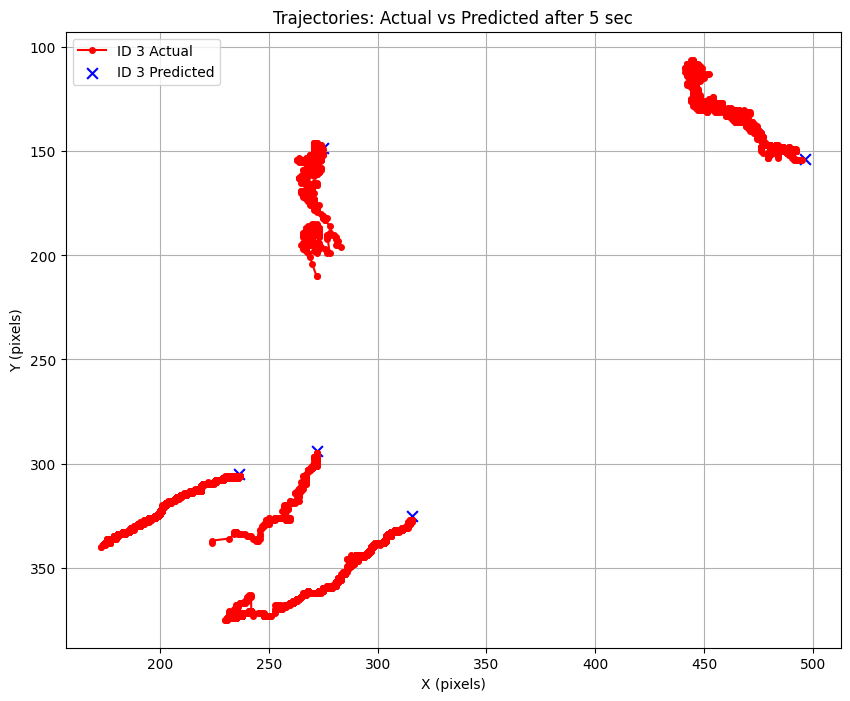

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Load your filtered dataframe
df_filtered = pd.read_csv("/content/drive/My Drive/new grad data/test/trajectories_roi_cleaned.csv")

# Load predictions
pred_df = pd.read_csv("/content/drive/My Drive/new grad data/test/predictions.csv")

ids_to_plot = df_filtered['ID'].unique()[:5]

plt.figure(figsize=(10, 8))

for tid in ids_to_plot:

    traj = df_filtered[df_filtered['ID'] == tid].sort_values("Frame")
    plt.plot(traj['X'], traj['Y'], '-o', color='red', markersize=4, label=f'ID {tid} Actual' if tid==ids_to_plot[0] else "")

    pred = pred_df[pred_df['ID'] == tid]
    if not pred.empty:
        plt.scatter(pred['Predicted_X'], pred['Predicted_Y'], color='blue', s=60, marker='x', label=f'ID {tid} Predicted' if tid==ids_to_plot[0] else "")

plt.gca().invert_yaxis()
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.title("Trajectories: Actual vs Predicted after 5 sec")
plt.legend()
plt.grid(True)
plt.show()


     ID     error
0     3  1.974586
1     6  1.215099
2    15  1.394265
3    17  1.272128
4    18  1.224274
5    37  3.149444
6    45  2.448796
7    53  3.104507
8    64  1.603740
9    85  4.156682
10   86  0.520463
11   87  1.259756
12  164  5.274854
13  178  3.926574
14  181  0.907521
15  186  2.110296
16  187  3.416149
17  194  3.707055
18  219  4.013367


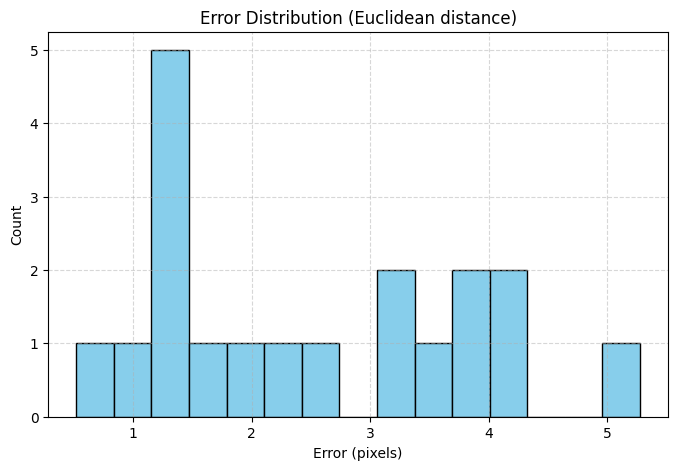

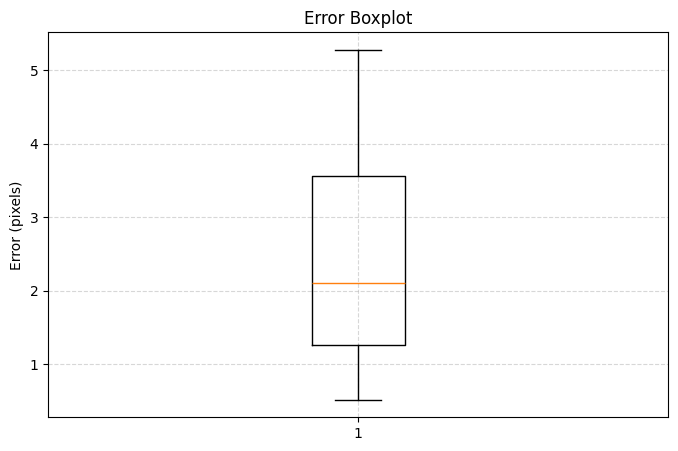

Mean Error: 2.456818616022068
Max Error: 5.274853527113337
Min Error: 0.5204633536570937


In [ ]:
# If not merged yet, merge the real last positions with predicted positions by ID
# We assume the last frame of each ID in df_filtered was used for prediction
last_real = df_filtered.groupby("ID").tail(1)[["ID", "X", "Y"]]

# Merge with predictions
merged = pd.merge(pred_df, last_real, on="ID", suffixes=('_pred', '_real'))

# Calculate Euclidean error for each ID
merged['error'] = np.sqrt((merged['Predicted_X'] - merged['X'])**2 +
                          (merged['Predicted_Y'] - merged['Y'])**2)

print(merged[['ID', 'error']])

# ======================
# Plot histogram of errors
# ======================
plt.figure(figsize=(8,5))
plt.hist(merged['error'], bins=15, color='skyblue', edgecolor='black')
plt.title("Error Distribution (Euclidean distance)")
plt.xlabel("Error (pixels)")
plt.ylabel("Count")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ======================
# Plot boxplot of errors
# ======================
plt.figure(figsize=(8,5))
plt.boxplot(merged['error'], vert=True)
plt.title("Error Boxplot")
plt.ylabel("Error (pixels)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ======================
# Show basic statistics
# ======================
print("Mean Error:", merged['error'].mean())
print("Max Error:", merged['error'].max())
print("Min Error:", merged['error'].min())

In [ ]:
import cv2
import numpy as np

# ================================
# Video paths
# ================================
video_path = output_video_path  # original tracking video
output_overlay_path = "/content/drive/My Drive/new grad data/test/tracking_with_prediction.mp4"


track = df_filtered[df_filtered["ID"] == chosen_id].sort_values("Frame")

# Predicted position after 5 seconds
pred_row = pred_df[pred_df["ID"] == chosen_id]
pred_x = int(pred_row["Predicted_X"].values[0])
pred_y = int(pred_row["Predicted_Y"].values[0])

# ================================
# Open video
# ================================
cap = cv2.VideoCapture(video_path)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = int(cap.get(cv2.CAP_PROP_FPS))

out = cv2.VideoWriter(
    output_overlay_path,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)

# ================================
# Draw overlay frame by frame
# ================================
frame_idx = 0
track_frames = track["Frame"].values
track_X = track["X"].values
track_Y = track["Y"].values

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    if frame_idx in track_frames:
        idx = np.where(track_frames == frame_idx)[0][0]
        x = int(track_X[idx])
        y = int(track_Y[idx])

        # Draw actual position (green)
        cv2.circle(frame, (x, y), 5, (0, 255, 0), -1)

        # Draw predicted position after 5 sec (blue)
        cv2.circle(frame, (pred_x, pred_y), 7, (255, 0, 0), 2)

        # Optional: draw line connecting current to predicted
        cv2.line(frame, (x, y), (pred_x, pred_y), (255, 0, 0), 1)

    out.write(frame)
    frame_idx += 1

cap.release()
out.release()
print("Overlay video saved:", output_overlay_path)


Overlay video saved: /content/drive/My Drive/new grad data/test/tracking_with_prediction.mp4


Overlay shows real-time trajectory of the chosen sperm (green) and its predicted position after 5 seconds (blue).

The connecting line visualizes direction and speed prediction.

This gives the committee a strong visual demonstration of the system's predictive capability.

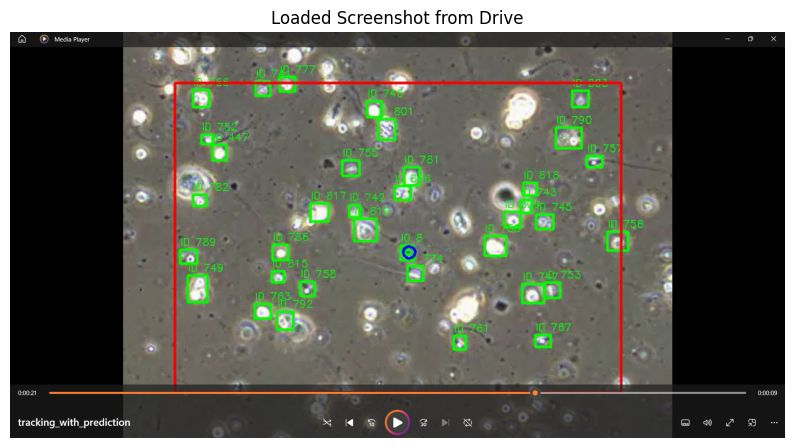

In [ ]:
# -----------------------------
# Load the image from Drive
# -----------------------------
image_path = "/content/drive/My Drive/new grad data/test/Screenshot 2026-02-12 010429.png"
img = cv2.imread(image_path)

# -----------------------------
# Convert BGR to RGB for correct colors
# -----------------------------
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# -----------------------------
# Display the image
# -----------------------------
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off')  # turn off axis
plt.title("Loaded Screenshot from Drive")
plt.show()
